# ¿Qué categorías concentran el gasto cultural y recreativo y cómo varían por territorio?

**Actividad final — Ciencia de Datos II**
**Actividad 11. Esparcimiento y cultura**
**Fuente:** INEI — ENAHO 2024, Módulo 606 *"Esparcimiento, diversión y servicios de cultura"*
**Archivo:** `11_ENAHO_esparcimiento_cultura.zip` → `Enaho01-2024-606.csv`

**Objetivo:** Describir patrones de gasto cultural y recreativo de los hogares peruanos en 2024, identificando qué categorías concentran el gasto y contrastando el departamento de **Puno** frente al **total nacional**.

**Pregunta de análisis:** ¿Qué categorías concentran el gasto cultural y recreativo y cómo varían por territorio?

---
### Sobre los datos
El Módulo 606 registra, para cada hogar encuestado, si adquirió (compró, autoconsumió, le regalaron, etc.) cada uno de **9 productos/servicios** de esparcimiento y cultura en el mes anterior a la entrevista, y valoriza monetariamente esa adquisición. Cada hogar aparece **9 veces** en la base (una fila por categoría de producto).

Categorías (`P606N`):
1. Periódicos, revistas y libros
2. Esparcimiento y diversión (cine, CDs, juguetes, espectáculos deportivos, etc.)
3. Aportaciones o cuotas a clubes / asociaciones
4. Gastos en gimnasios
5. USB
6. Artículos deportivos
7. Útiles de escritorio
8. Otros gastos
9. Servicio de streaming (Spotify, Netflix, etc.)

Variables usadas:
- `I606B` : monto pagado por la compra (imputado, deflactado y anualizado, en soles)
- `I606C` : valor imputado del producto/servicio cuando **no** fue comprado (regalo, autoconsumo, donación, etc.), también imputado/deflactado/anualizado
- `DOMINIO` : dominio geográfico (8 categorías: Costa Norte/Centro/Sur, Sierra Norte/Centro/Sur, Selva, Lima Metropolitana)
- `UBIGEO` : ubicación geográfica (los 2 primeros dígitos identifican el departamento; Puno = `21`)
- `FACTOR07` : factor de expansión del hogar (usado para obtener estimaciones representativas de la población)

Se usa `I606B + I606C` como **gasto valorizado anual del hogar en esa categoría** (soles), ya que ambas variables son mutuamente excluyentes a nivel de categoría (una capta lo comprado y la otra lo obtenido por otros medios) y ya vienen deflactadas para permitir comparaciones entre regiones y meses de encuesta.

## 1. Carga de librerías y datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110

# El archivo original del INEI viene en codificación Latin-1 (ISO-8859-1)
df = pd.read_csv('Enaho01-2024-606.csv', encoding='latin-1')
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (303219, 47)


,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,UBIGEO,DOMINIO,ESTRATO,P606N,P606,P606A1,P606A2,P606A3,P606A4,P606A5,P606A6,P606A7,P606A8,P606AA,P606B,P606C2,P606C3,P606C4,P606C5,P606C6,P606C7,P606C,TICUEST01,D606B,D606C2,D606C3,D606C4,D606C5,D606C6,D606C7,D606C,I606B,I606C2,I606C3,I606C4,I606C5,I606C6,I606C7,I606C,FACTOR07,NCONGLOME,SUB_CONGLOME
0,2024,1,15009,13,11,10101,4,4,1,2,,,,,,,,,,,,,,,,,,2,,,,,,,,,,,,,,,,,79.816757,7098,0
1,2024,1,15009,13,11,10101,4,4,2,2,,,,,,,,,,,,,,,,,,2,,,,,,,,,,,,,,,,,79.816757,7098,0
2,2024,1,15009,13,11,10101,4,4,3,2,,,,,,,,,,,,,,,,,,2,,,,,,,,,,,,,,,,,79.816757,7098,0
3,2024,1,15009,13,11,10101,4,4,4,2,,,,,,,,,,,,,,,,,,2,,,,,,,,,,,,,,,,,79.816757,7098,0
4,2024,1,15009,13,11,10101,4,4,5,2,,,,,,,,,,,,,,,,,,2,,,,,,,,,,,,,,,,,79.816757,7098,0


## 2. Limpieza y preparación de variables

In [ ]:
# --- 2.1 Variables monetarias: vienen como texto con espacios en blanco para "missing" ---
for col in ['I606B', 'I606C']:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce').fillna(0)

# Gasto valorizado anual del hogar en cada categoría (soles, deflactado)
df['gasto_anual'] = df['I606B'] + df['I606C']

# --- 2.2 Identificador de hogar (cada hogar aparece 9 veces, una por categoría) ---
df['hh_id'] = (df['CONGLOME'].astype(str) + '-' +
               df['VIVIENDA'].astype(str) + '-' +
               df['HOGAR'].astype(str))

# --- 2.3 Departamento a partir de UBIGEO (2 primeros dígitos) y bandera Puno ---
df['UBIGEO_STR'] = df['UBIGEO'].astype(str).str.zfill(6)
df['DEP_COD'] = df['UBIGEO_STR'].str[:2]
df['es_puno'] = df['DEP_COD'] == '21'   # 21 = Puno en la codificación INEI

# --- 2.4 Etiquetas legibles de categoría de gasto y dominio geográfico ---
cat_map = {
    1: 'Periódicos, revistas\ny libros',
    2: 'Esparcimiento\ny diversión',
    3: 'Cuotas a clubes /\nasociaciones',
    4: 'Gimnasios',
    5: 'USB',
    6: 'Artículos deportivos',
    7: 'Útiles de escritorio',
    8: 'Otros gastos',
    9: 'Streaming',
}
df['categoria'] = df['P606N'].map(cat_map)

dom_map = {
    1: 'Costa Norte', 2: 'Costa Centro', 3: 'Costa Sur',
    4: 'Sierra Norte', 5: 'Sierra Centro', 6: 'Sierra Sur',
    7: 'Selva', 8: 'Lima Metropolitana',
}
df['dominio_nom'] = df['DOMINIO'].map(dom_map)

# --- 2.5 Chequeos de calidad ---
print('Hogares únicos en la base:', df['hh_id'].nunique())
print('Filas totales (hogares x 9 categorías):', df.shape[0])
print('Hogares en Puno (dep. 21):', df.loc[df['es_puno'], 'hh_id'].nunique())
print('Valores nulos tras limpieza (gasto_anual):', df['gasto_anual'].isna().sum())
print('% de filas con gasto_anual > 0:', round((df['gasto_anual'] > 0).mean() * 100, 2), '%')

Hogares únicos en la base: 33691
Filas totales (hogares x 9 categorías): 303219
Hogares en Puno (dep. 21): 1123
Valores nulos tras limpieza (gasto_anual): 0
% de filas con gasto_anual > 0: 5.18 %


## 3. Agregación de resultados

Se construyen estimaciones **ponderadas** con el factor de expansión anual (`FACTOR07`), de modo que las cifras representen a la población de hogares del Perú (y no solo a la muestra encuestada), tal como recomienda la metodología de ENAHO.

In [ ]:
df['gasto_pond'] = df['gasto_anual'] * df['FACTOR07']

# --- 3.1 Gasto total ponderado por categoría: Nacional ---
tot_nac = df.groupby('categoria')['gasto_pond'].sum().sort_values(ascending=False)
share_nac = (tot_nac / tot_nac.sum() * 100).round(2)

# --- 3.2 Gasto total ponderado por categoría: Puno ---
tot_puno = df.loc[df['es_puno']].groupby('categoria')['gasto_pond'].sum()
tot_puno = tot_puno.reindex(tot_nac.index).fillna(0)
share_puno = (tot_puno / tot_puno.sum() * 100).round(2)

# --- 3.3 Gasto promedio anual por hogar (S/.), nacional y Puno ---
def gasto_promedio_hogar(sub):
    g = sub.groupby('hh_id').agg(gasto_hog=('gasto_anual', 'sum'), w=('FACTOR07', 'first'))
    return (g['gasto_hog'] * g['w']).sum() / g['w'].sum()

avg_nac = gasto_promedio_hogar(df)
avg_puno = gasto_promedio_hogar(df.loc[df['es_puno']])

# --- 3.4 Tabla resumen ---
tabla = pd.DataFrame({
    'Gasto anual/hogar Nacional (S/)': (tot_nac / df['hh_id'].nunique()).round(2),  # referencia bruta, no usada para conclusión
    '% del gasto - Nacional': share_nac,
    '% del gasto - Puno': share_puno,
    'Diferencia (pp, Puno-Nac)': (share_puno - share_nac).round(2),
})
tabla = tabla.drop(columns=['Gasto anual/hogar Nacional (S/)'])
tabla = tabla.sort_values('% del gasto - Nacional', ascending=False)

print(f'Gasto promedio anual por hogar en esparcimiento y cultura:')
print(f'  Nacional: S/ {avg_nac:,.2f}')
print(f'  Puno:     S/ {avg_puno:,.2f}  ( {avg_puno/avg_nac*100:.1f}% del promedio nacional )')
print()
tabla

Gasto promedio anual por hogar en esparcimiento y cultura:
  Nacional: S/ 248.12
  Puno:     S/ 125.58  ( 50.6% del promedio nacional )



,% del gasto - Nacional,% del gasto - Puno,"Diferencia (pp, Puno-Nac)"
categoria,,,
Otros gastos,35.49,59.89,24.40
Esparcimiento\ny diversión,31.94,20.52,-11.42
Streaming,10.81,3.52,-7.29
Gimnasios,7.68,2.60,-5.08
"Periódicos, revistas\ny libros",7.64,4.75,-2.89
Cuotas a clubes /\nasociaciones,2.65,3.14,0.49
Artículos deportivos,1.85,3.81,1.96
Útiles de escritorio,1.69,1.40,-0.29
USB,0.25,0.36,0.11


**Tabla 1.** Composición porcentual del gasto valorizado en esparcimiento y cultura, por categoría — Nacional vs. Puno (estimaciones ponderadas con `FACTOR07`, ENAHO 2024).

La tabla muestra que a nivel nacional el gasto se concentra en **"Otros gastos"** y **"Esparcimiento y diversión"**, mientras que en Puno la concentración en "Otros gastos" es todavía mayor y categorías como streaming, gimnasios y cuotas a clubes prácticamente no participan.

## 4. Gráfico 1 — Composición del gasto por categoría: Nacional vs. Puno

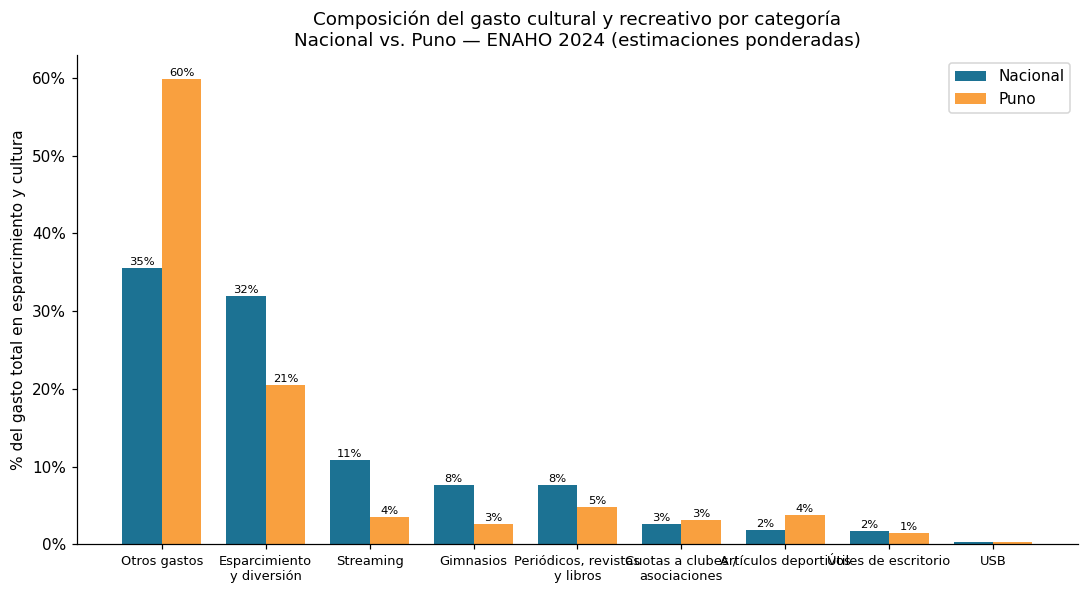

In [ ]:
orden = tabla.index.tolist()
x = np.arange(len(orden))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - w/2, tabla['% del gasto - Nacional'], width=w, label='Nacional', color='#1C7293')
b2 = ax.bar(x + w/2, tabla['% del gasto - Puno'], width=w, label='Puno', color='#F9A03F')

ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=0, fontsize=8.5)
ax.set_ylabel('% del gasto total en esparcimiento y cultura')
ax.set_title('Composición del gasto cultural y recreativo por categoría\nNacional vs. Puno — ENAHO 2024 (estimaciones ponderadas)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.annotate(f'{h:.0f}%', (bar.get_x() + bar.get_width()/2, h),
                        textcoords='offset points', xytext=(0, 2), ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('grafico1_composicion_categoria.png', dpi=150)
plt.show()

## 5. Gráfico 2 — Gasto promedio anual por hogar según territorio

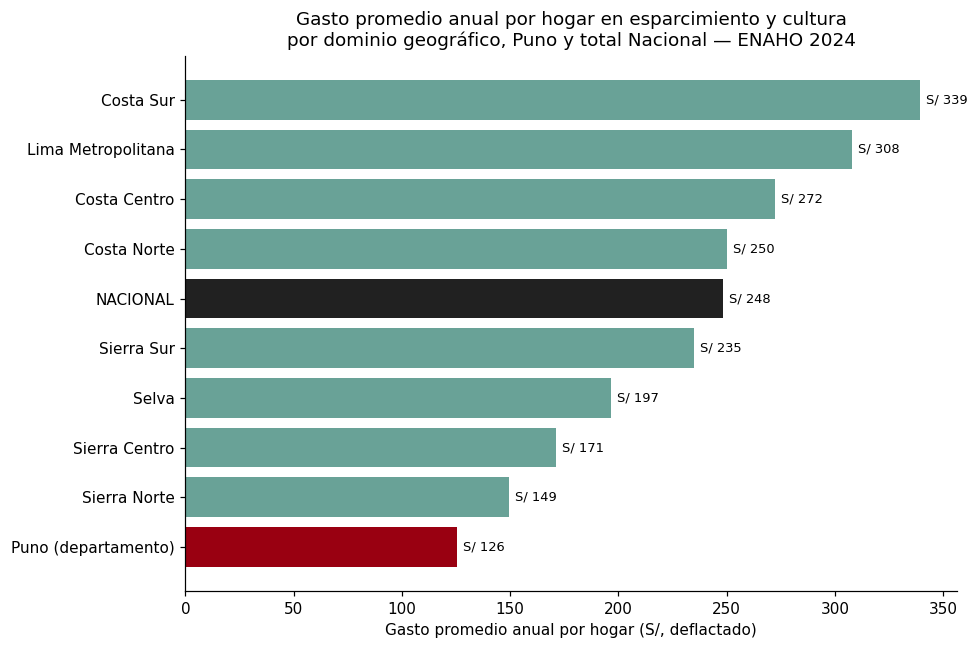

In [ ]:
# Gasto promedio por hogar en cada dominio geográfico
dom_avg = (df.groupby(['hh_id', 'dominio_nom'])
             .agg(gasto_hog=('gasto_anual', 'sum'), w=('FACTOR07', 'first'))
             .reset_index())

res_dom = (dom_avg.groupby('dominio_nom')
           .apply(lambda g: (g['gasto_hog'] * g['w']).sum() / g['w'].sum())
           .sort_values(ascending=False))

# Se añade Puno como barra adicional (departamento específico, no un dominio completo)
serie = res_dom.copy()
serie['Puno (departamento)'] = avg_puno
serie['NACIONAL'] = avg_nac
serie = serie.sort_values(ascending=True)

colors = ['#B85042' if (nombre in ('Puno (departamento)', 'NACIONAL')) else '#84B59F'
          for nombre in serie.index]
colors = ['#990011' if n == 'Puno (departamento)' else ('#212121' if n == 'NACIONAL' else '#69A297')
          for n in serie.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(serie.index, serie.values, color=colors)
ax.set_xlabel('Gasto promedio anual por hogar (S/, deflactado)')
ax.set_title('Gasto promedio anual por hogar en esparcimiento y cultura\npor dominio geográfico, Puno y total Nacional — ENAHO 2024')
ax.spines[['top', 'right']].set_visible(False)

for bar in bars:
    w_ = bar.get_width()
    ax.annotate(f'S/ {w_:,.0f}', (w_, bar.get_y() + bar.get_height()/2),
                textcoords='offset points', xytext=(4, 0), va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('grafico2_gasto_territorio.png', dpi=150)
plt.show()

**Gráfico 2.** El departamento de Puno registra el gasto promedio anual por hogar en esparcimiento y cultura **más bajo** de la comparación, muy por debajo tanto del promedio nacional como del promedio de su propio dominio geográfico (Sierra Sur, que incluye departamentos como Cusco y Apurímac). Esto sugiere heterogeneidad *dentro* del dominio Sierra Sur: agregar a nivel de dominio puede ocultar diferencias entre departamentos.

## 6. Exploración adicional (opcional) — agrupamiento de departamentos según composición del gasto

Como técnica exploratoria adicional (no indispensable para responder la pregunta, dado que el problema no requiere un modelo complejo), se agrupan los 25 departamentos mediante **K-Means** usando como variables el % de participación de cada categoría de gasto dentro de su gasto cultural-recreativo total. Esto permite ver si Puno se agrupa con departamentos de perfil de gasto similar.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

dep_map = {
    '01':'Amazonas','02':'Áncash','03':'Apurímac','04':'Arequipa','05':'Ayacucho',
    '06':'Cajamarca','07':'Callao','08':'Cusco','09':'Huancavelica','10':'Huánuco',
    '11':'Ica','12':'Junín','13':'La Libertad','14':'Lambayeque','15':'Lima',
    '16':'Loreto','17':'Madre de Dios','18':'Moquegua','19':'Pasco','20':'Piura',
    '21':'Puno','22':'San Martín','23':'Tacna','24':'Tumbes','25':'Ucayali'
}
df['departamento'] = df['DEP_COD'].map(dep_map)

# Gasto ponderado por departamento y categoría -> matriz de composición (%)
dep_cat = df.groupby(['departamento', 'categoria'])['gasto_pond'].sum().unstack(fill_value=0)
dep_cat_pct = dep_cat.div(dep_cat.sum(axis=1), axis=0) * 100

scaler = StandardScaler()
X = scaler.fit_transform(dep_cat_pct.values)

k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = km.fit_predict(X)
dep_cat_pct['cluster'] = clusters

print('Departamentos agrupados por perfil de gasto cultural-recreativo (K-Means, k=3):\n')
for c in sorted(dep_cat_pct['cluster'].unique()):
    deps = dep_cat_pct.index[dep_cat_pct['cluster'] == c].tolist()
    marca = '  <-- incluye PUNO' if 'Puno' in deps else ''
    print(f'Cluster {c}: {", ".join(deps)}{marca}')

Departamentos agrupados por perfil de gasto cultural-recreativo (K-Means, k=3):

Cluster 0: Amazonas, Huánuco, Madre de Dios, Moquegua, San Martín, Áncash
Cluster 1: Apurímac, Arequipa, Cajamarca, Callao, Ica, Junín, La Libertad, Lambayeque, Lima, Loreto, Pasco, Piura, Tumbes, Ucayali
Cluster 2: Ayacucho, Cusco, Huancavelica, Puno, Tacna  <-- incluye PUNO


El agrupamiento es exploratorio y descriptivo: confirma que Puno comparte un perfil de gasto con otros departamentos de menores ingresos/mayor ruralidad, reforzando —sin implicar causalidad— la asociación entre territorio y composición del gasto cultural-recreativo observada en los gráficos anteriores.

## 7. Conclusión

**Respuesta a la pregunta de análisis:**

A nivel nacional, el gasto cultural y recreativo de los hogares peruanos en 2024 se concentra fuertemente en dos categorías: **"Otros gastos"** (≈35% del gasto total valorizado, categoría residual que agrupa consumos diversos no clasificados en las demás) y **"Esparcimiento y diversión"** (cine, discos, juguetes, espectáculos deportivos, ≈32%), seguidas a mayor distancia por **streaming** (≈11%) y **gimnasios/periódicos-revistas-libros** (≈8% cada una). Las categorías de **cuotas a clubes, artículos deportivos, útiles de escritorio y USB** son marginales (todas por debajo de 3%).

Al contrastar por territorio, **Puno se aparta claramente del patrón nacional**: concentra cerca del **60% de su gasto cultural-recreativo en "Otros gastos"** (casi el doble que el promedio nacional) y prácticamente no gasta en streaming, gimnasios o cuotas a clubes/asociaciones —categorías más asociadas a zonas urbanas con mayor oferta de servicios y conectividad—. Además, el **gasto promedio anual por hogar en Puno (S/ 125.6) equivale a poco más de la mitad del promedio nacional (S/ 248.1)**, y es también inferior al promedio de su propio dominio geográfico (Sierra Sur), lo que indica que agregar a nivel de dominio oculta parte de la brecha específica de Puno.

En síntesis: el gasto cultural-recreativo no solo es menor en magnitud en Puno, sino que tiene una composición más concentrada y menos diversificada que el promedio del país, con escasa presencia de servicios de suscripción y actividades físico-recreativas de pago.

**Limitaciones:**
- Los datos son **observacionales y transversales** (un solo corte, 2024); las diferencias descritas son **asociaciones**, no relaciones causales — no puede afirmarse que "ser de Puno" *cause* un menor gasto cultural, ya que factores como ingreso del hogar, ruralidad, acceso a internet/electricidad o estructura etaria del hogar no se controlan en este análisis descriptivo.
- El gasto se basa en **reporte del hogar** (recuerdo del mes anterior) y en **valores imputados/deflactados** por el INEI para partidas no compradas (regalos, autoconsumo), lo que introduce un margen de error de medición, especialmente en la categoría residual "Otros gastos".
- La comparación territorial usa el **departamento** (vía UBIGEO) para aislar a Puno, pero el **dominio geográfico** (Sierra Sur) agrupa a varios departamentos con perfiles distintos; los resultados por dominio deben leerse solo como referencia contextual, no como una medida específica de Puno.
- El agrupamiento (clustering) es una técnica exploratoria adicional con pocos casos (25 departamentos) y no debe interpretarse como un modelo predictivo o causal.

**Referencias:**
- Instituto Nacional de Estadística e Informática (INEI). (2024). *Encuesta Nacional de Hogares (ENAHO) 2024 — Módulo 606: Esparcimiento, diversión y servicios de cultura* [Microdatos]. https://proyectos.inei.gob.pe/microdatos/
- INEI. (2024). *Ficha técnica ENAHO 2024*.
- INEI. (2024). *Diccionario de datos ENAHO 2024*.